In [17]:
# CAMB = (code for anisotropies in the microwave background)

In [47]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import os
import numpy as np
from matplotlib import pyplot as plt
import camb
from camb import model, initialpower

print('Using CAMB %s installed at %s' % (camb.__version__, os.path.dirname(camb.__file__)))
# make sure the version and path is what you expect



Using CAMB 1.6.5 installed at /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/camb


In [48]:
# Set up a new set of parameters for CAMB
# The defaults give one massive neutrino and helium set using BBN consistency
pars = camb.set_params(
    H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06, As=2e-9, ns=0.965, halofit_version='mead', lmax=3000
)

results = camb.get_results(pars)

# get dictionary of CAMB power spectra
powers = results.get_cmb_power_spectra(pars, CMB_unit='muK')
for name in powers:
    print(name)

total
unlensed_scalar
unlensed_total
lensed_scalar
tensor
lens_potential


In [49]:
powers

{'total': array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00],
        [ 9.71257212e+02,  3.19837763e-02,  1.56725061e-06,
          2.60301502e+00],
        ...,
        [ 2.23569042e+01,  7.23465403e-01,  1.17549187e-02,
         -1.14620955e+00],
        [ 2.23038966e+01,  7.21604144e-01,  1.17396404e-02,
         -1.13959441e+00],
        [ 2.22507866e+01,  7.19778385e-01,  1.17243771e-02,
         -1.13304128e+00]], shape=(3051, 4)),
 'unlensed_scalar': array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00],
        [ 9.71254263e+02,  3.19822091e-02,  0.00000000e+00,
          2.60301504e+00],
        ...,
        [ 2.08527081e+01,  5.48974735e-01,  0.00000000e+00,
         -9.63116195e-01],
        [ 2.07902289e+01,  5.47524831e-01,  0.00000000e+0

(3051, 4)


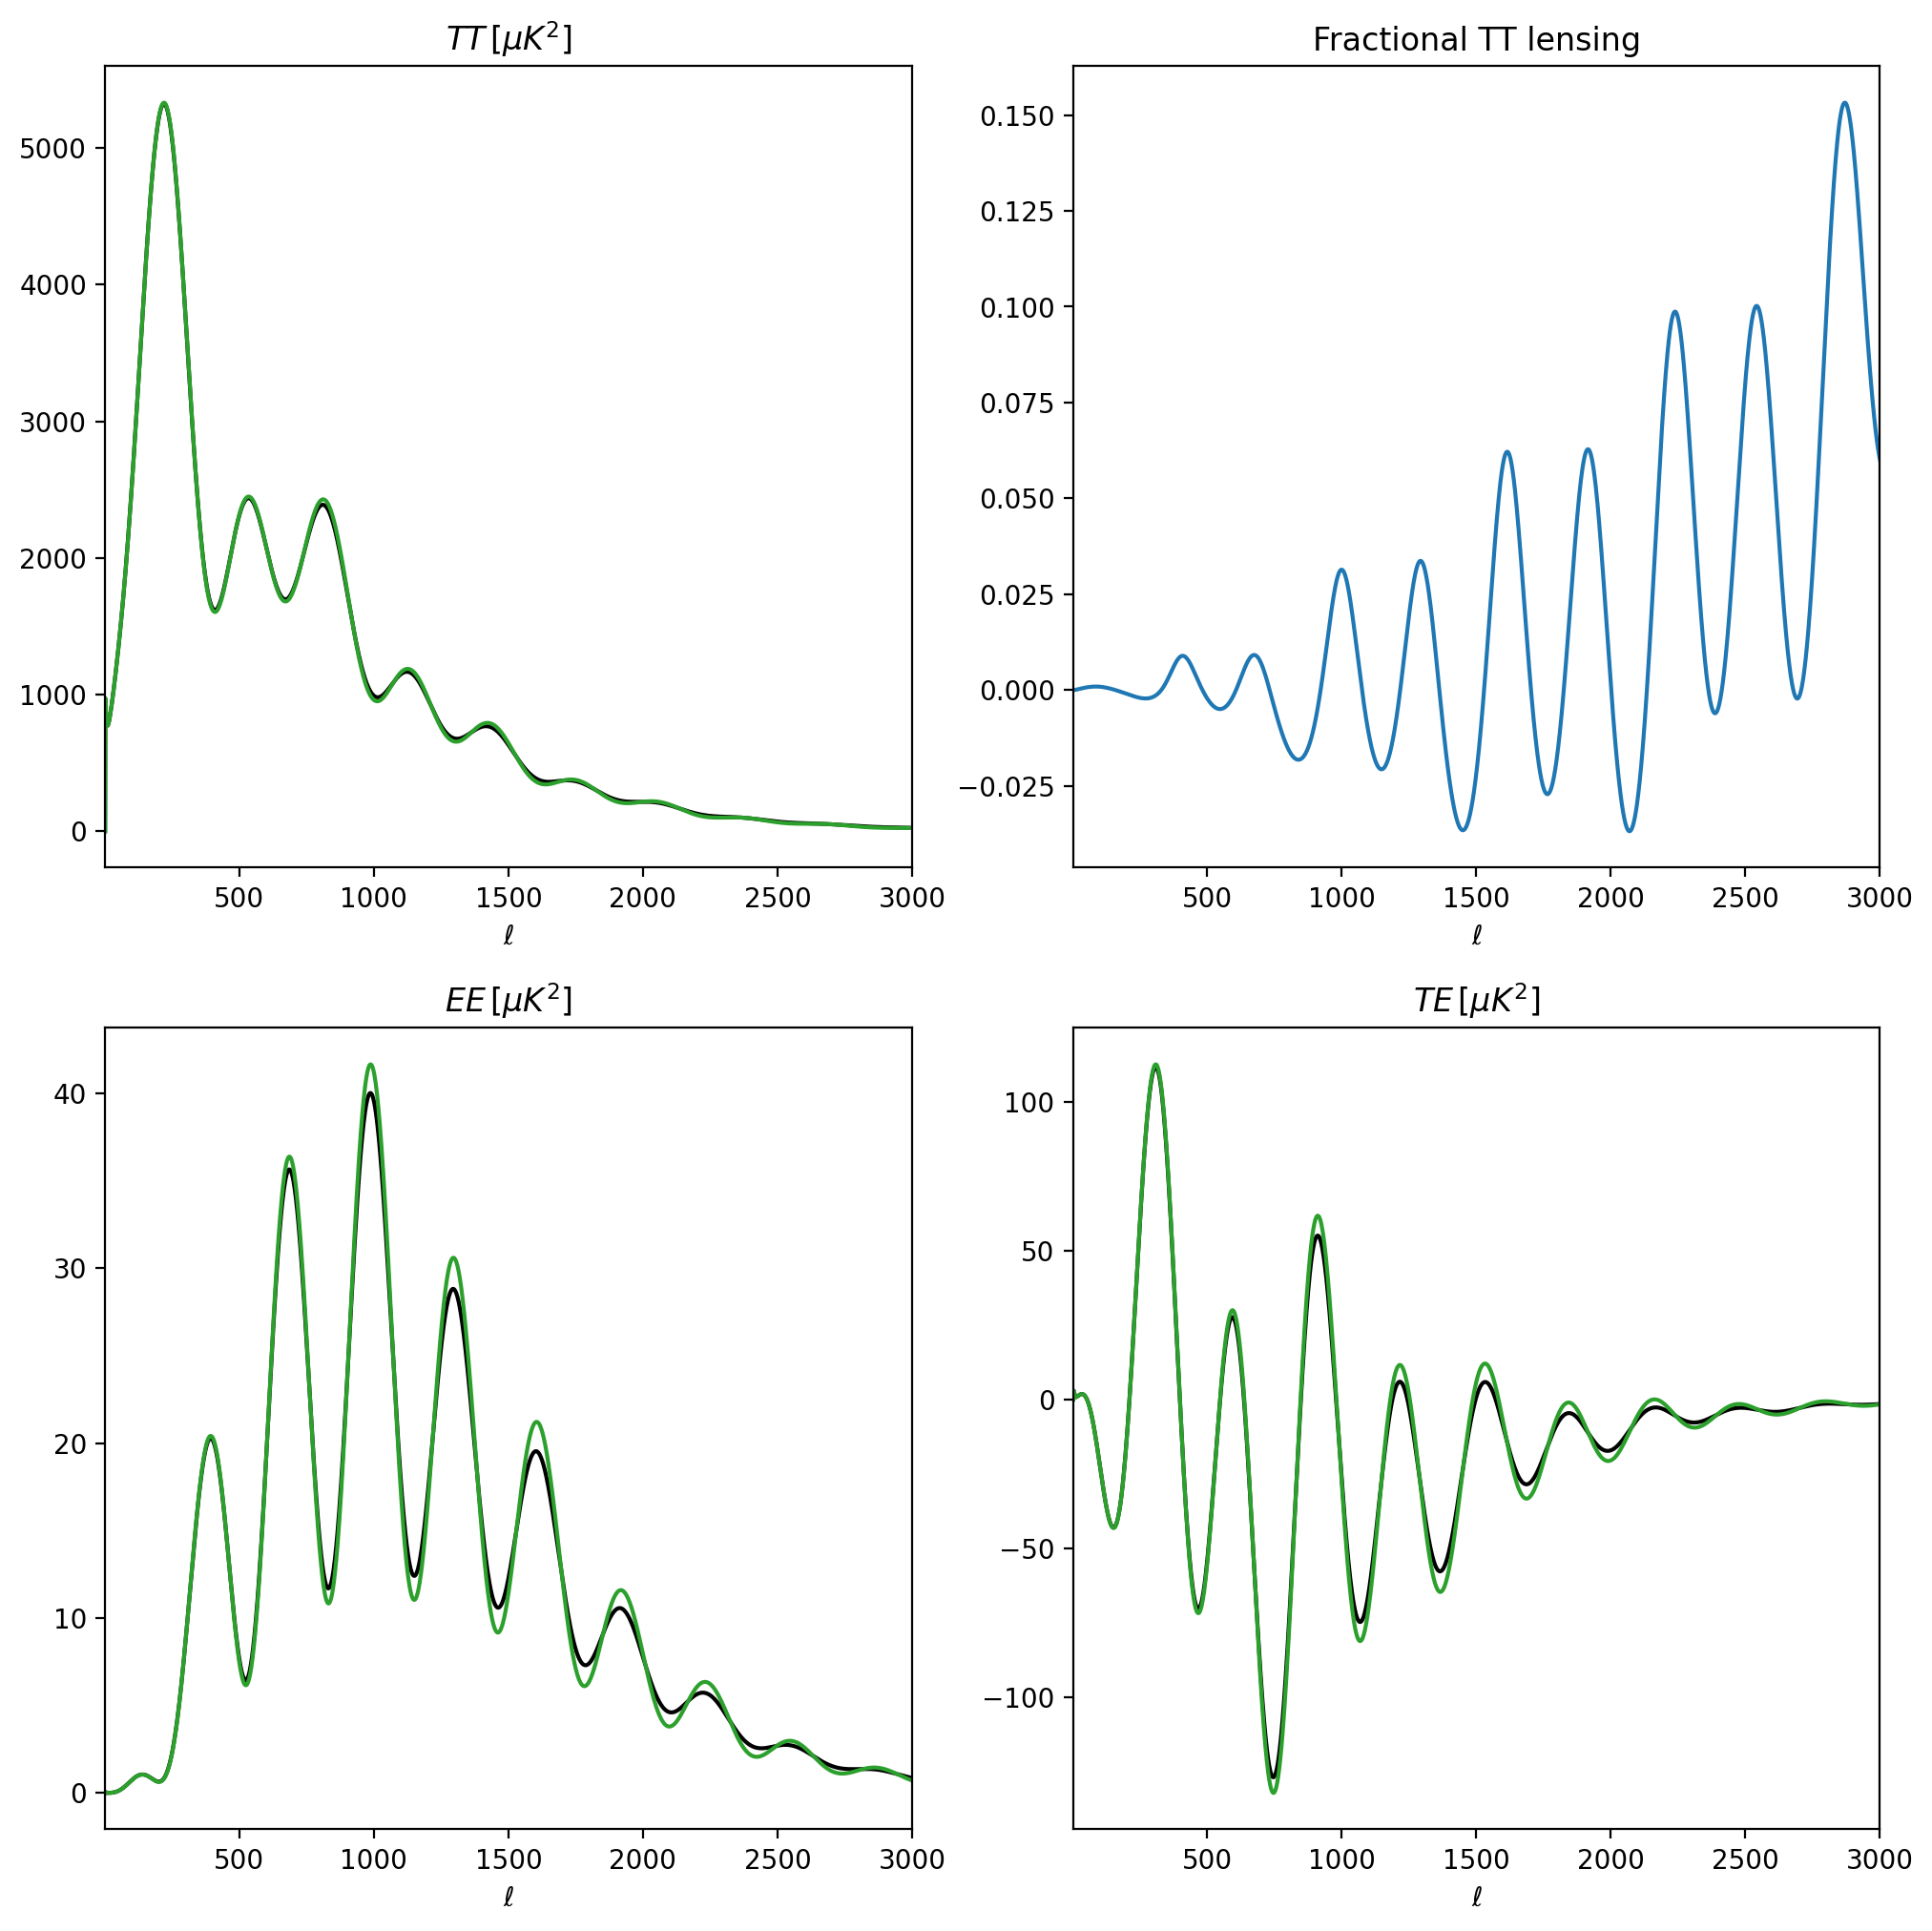

In [50]:
# plot the total lensed CMB power spectra versus unlensed, and fractional difference
totCL = powers['total']
unlensedCL = powers['unlensed_scalar']
print(totCL.shape)
# Python CL arrays are all zero based (starting at L=0), Note L=0,1 entries will be zero by default.
# The different CL are always in the order TT, EE, BB, TE (with BB=0 for unlensed scalar results).
ls = np.arange(totCL.shape[0])
fig, ax = plt.subplots(2, 2, figsize=(12, 12))
ax[0, 0].plot(ls, totCL[:, 0], color='k')
ax[0, 0].plot(ls, unlensedCL[:, 0], color='C2')
ax[0, 0].set_title(r'$TT\, [\mu K^2]$')
ax[0, 1].plot(ls[2:], 1 - unlensedCL[2:, 0] / totCL[2:, 0])
ax[0, 1].set_title(r'Fractional TT lensing')
ax[1, 0].plot(ls, totCL[:, 1], color='k')
ax[1, 0].plot(ls, unlensedCL[:, 1], color='C2')
ax[1, 0].set_title(r'$EE\, [\mu K^2]$')
ax[1, 1].plot(ls, totCL[:, 3], color='k')
ax[1, 1].plot(ls, unlensedCL[:, 3], color='C2')
ax[1, 1].set_title(r'$TE\, [\mu K^2]$')
for ax in ax.reshape(-1):
    ax.set_xlim([2, 3000])
    ax.set_xlabel(r'$\ell$')

In [51]:
ls

array([   0,    1,    2, ..., 3048, 3049, 3050], shape=(3051,))

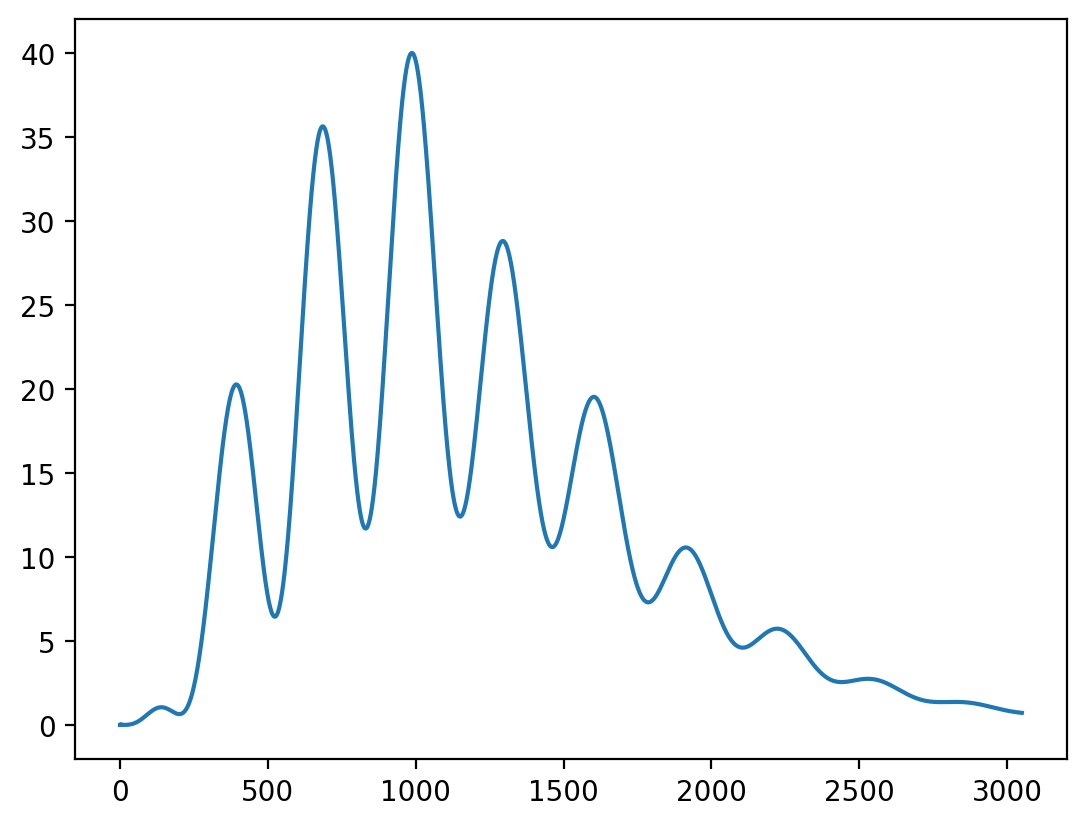

In [52]:
plt.plot(ls,totCL[:,1])

In [53]:
# Calculate Cl


# If you want to use sigma8 (redshift zero) as an input parameter, have to scale the input primordial amplitude As:

As = 2e-9  # fiducial amplitude guess to start with
pars = camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, ns=0.965, As=As)
pars.set_matter_power(redshifts=[0.0], kmax=2.0)
results = camb.get_results(pars)
s8_fid = results.get_sigma8_0()
# now set correct As using As \propto sigma8**2.
sigma8 = 0.81  # value we want
pars.InitPower.set_params(As=As * sigma8**2 / s8_fid**2, ns=0.965)

# check result
results = camb.get_results(pars)
print(sigma8, results.get_sigma8_0())

0.81 0.81


(2, 2000)

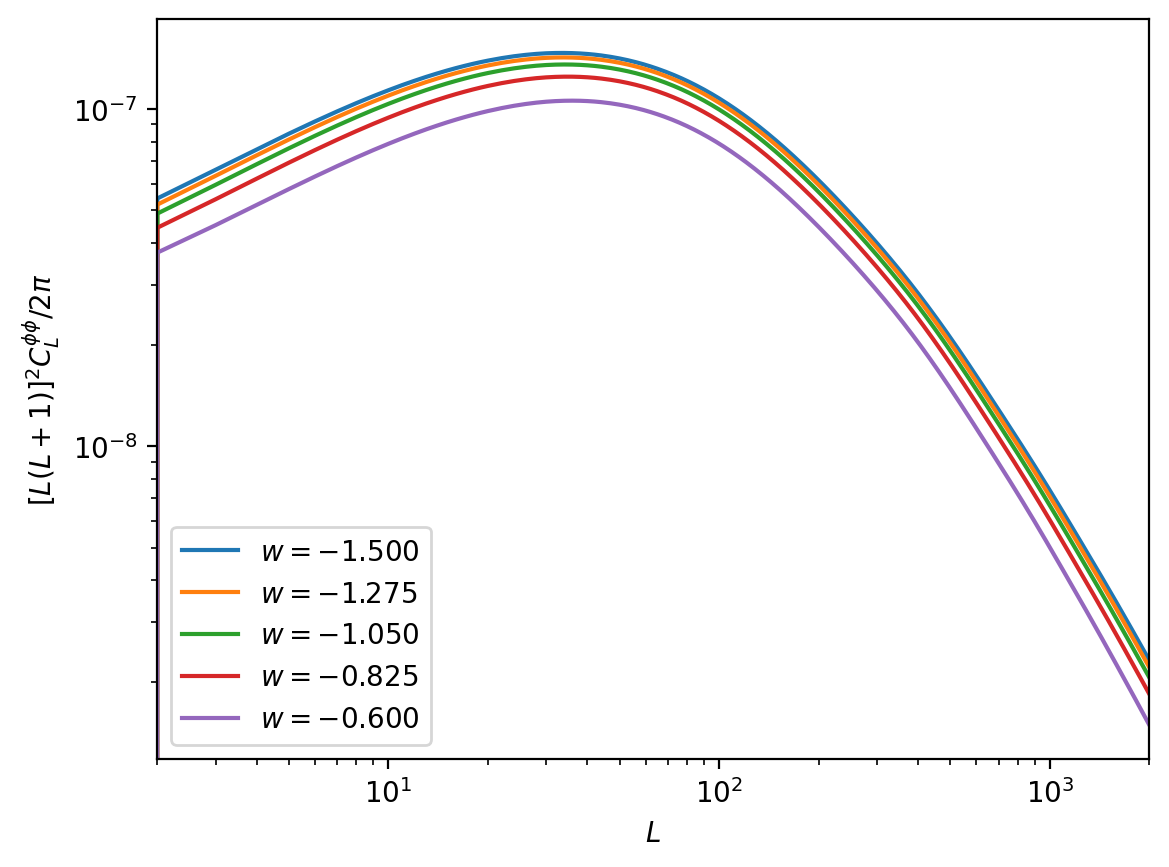

In [54]:
# Plot CMB lensing potential power for various values of w at fixed H0

pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122)
pars.InitPower.set_params(As=2e-9, ns=0.965)
pars.set_for_lmax(2000, lens_potential_accuracy=1)

ws = np.linspace(-1.5, -0.6, 5)
for w in ws:
    pars.set_dark_energy(w=w, wa=0, dark_energy_model='fluid')
    results = camb.get_results(pars)
    cl = results.get_lens_potential_cls(lmax=2000)
    plt.loglog(np.arange(2001), cl[:, 0])

plt.legend([f'$w = {w:.3f}$' for w in ws])
plt.ylabel(r'$[L(L+1)]^2C_L^{\phi\phi}/2\pi$')
plt.xlabel('$L$')
plt.xlim([2, 2000])